# Overview

Name: José Alecander Quishpe Reinoso

Date: 23-06-2026

## Phase 1: Setup & Evaluation

Before testing the models, we need to prepare our data and understand how we are going to measure their performance. To analyze each algorithm, we will use two main visual tools:

* **Confusion Matrix:** This is a table that shows you *exactly* where the model makes mistakes. It breaks down the predictions so you can clearly see the correct guesses (true positives/negatives) and the errors (false alarms or misses).
* **ROC Curve & AUC:** 
    * The **ROC Curve** is a graph that shows the relationship between the model's correct predictions and its false alarms.
    * The **AUC** (Area Under the Curve) summarizes that graph into a single, easy-to-read score: a score of **1.0** means the model is perfect, while a **0.5** (represented by a diagonal line) means the model is useless, just like flipping a random coin.

> **Note:** Run this code block first to generate the dataset and load all the necessary mathematical tools.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# FIXED: All required metrics are imported here so you won't get NameErrors
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc 

# Set global visual style for clean, academic graphs
sns.set_theme(style="whitegrid")

# 1. Generate a synthetic dataset (1000 samples, 20 features)
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# 2. Split into Training (80%) and Testing (20%) sets to prevent overfitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully prepared. All evaluation metrics loaded.")

Data successfully prepared. All evaluation metrics loaded.


## Phase 2: The Models

### 1. Single Tree (Decision Tree)

**Theoretical Overview:** It creates a single, highly interpretable model by splitting the data based on simple if/then conditional rules. While easy to understand, a single tree is notoriously prone to overfitting—it memorizes the training data and struggles with high variance.

**Graph Analysis:**

* **Confusion Matrix:** You will notice higher numbers in the error squares (the off-diagonal boxes) compared to the advanced ensembles we will test next.
* **ROC Curve:** The curve will likely be somewhat rigid and closer to the diagonal gray line, resulting in a lower AUC score.

Single Tree Accuracy: 0.8750


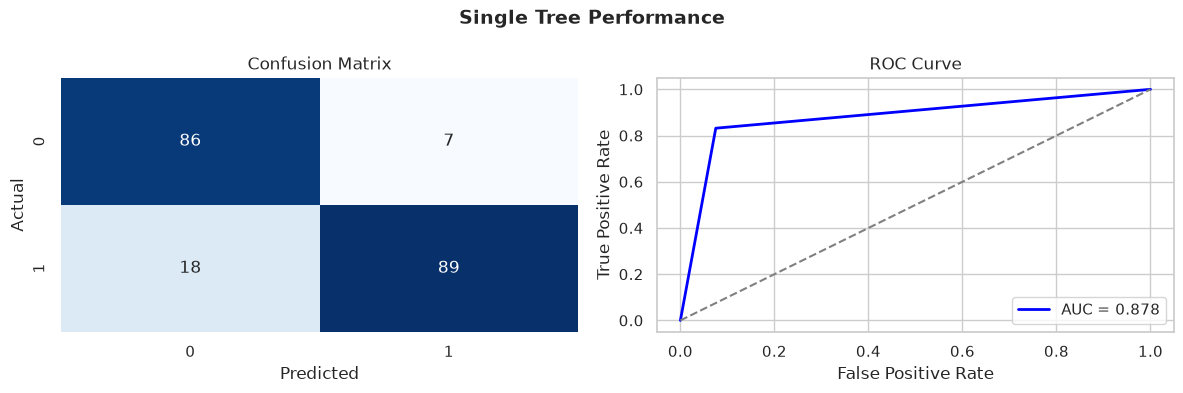

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc 
import matplotlib.pyplot as plt
import seaborn as sns

# Train
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# Predict classes and probabilities
preds_tree = tree_model.predict(X_test)
probs_tree = tree_model.predict_proba(X_test)[:, 1] # Needed for ROC

print(f"Single Tree Accuracy: {accuracy_score(y_test, preds_tree):.4f}")

# Setup Figure: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graph 1: Confusion Matrix
cm_tree = confusion_matrix(y_test, preds_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Graph 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs_tree)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc="lower right")

fig.suptitle('Single Tree Performance', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### 2. Bagging (Bootstrap Aggregating)

**Theoretical Overview:** Bagging trains multiple independent trees in parallel on random subsets of the training data. By having all these diverse trees "vote" on the final prediction, it effectively reduces variance and combats the overfitting seen in individual trees.

**Graph Analysis:**

* **Confusion Matrix:** The errors (false positives and false negatives) will visually shrink.
* **ROC Curve:** The curve will push noticeably further into the top-left corner, and the AUC score will increase, proving this is a much more reliable model.

Bagging Accuracy: 0.8850


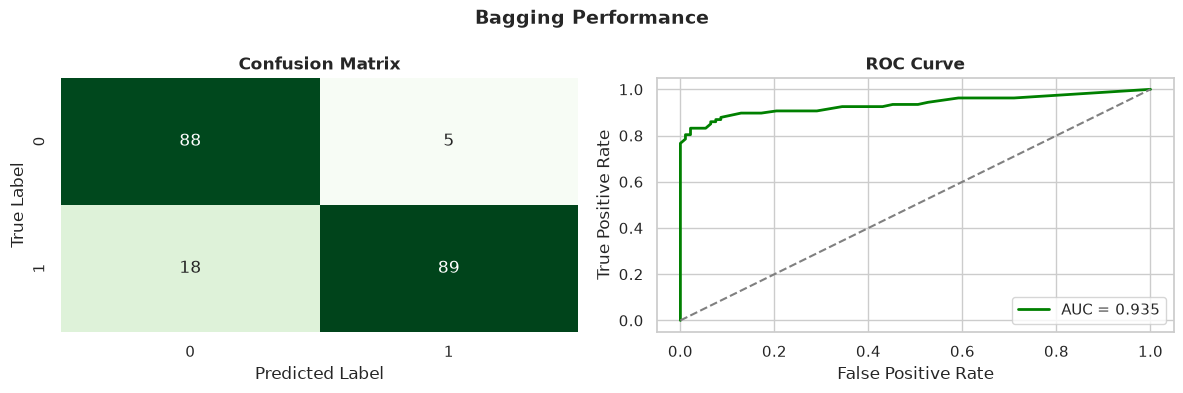

In [3]:
from sklearn.ensemble import BaggingClassifier

# Train the model
bagging_model = BaggingClassifier(n_estimators=50, random_state=42)
bagging_model.fit(X_train, y_train)

# Predict
preds_bagging = bagging_model.predict(X_test)
probs_bagging = bagging_model.predict_proba(X_test)[:, 1]

print(f"Bagging Accuracy: {accuracy_score(y_test, preds_bagging):.4f}")

# Setup Figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graph 1: Confusion Matrix
cm_bagging = confusion_matrix(y_test, preds_bagging)
sns.heatmap(cm_bagging, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Graph 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs_bagging)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='green', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc="lower right")

fig.suptitle('Bagging Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Random Forest

**Theoretical Overview:** This is a powerful evolution of the Bagging concept. It still trains multiple trees in parallel, but at each split, the tree is only allowed to consider a random subset of features. This forced decorrelation reduces variance even further, making Random Forest an incredibly robust algorithm.

**Graph Analysis:**

* **Confusion Matrix:** You will see a very clean matrix. The error numbers will be highly minimized compared to standard Bagging, showcasing its strength as a highly robust, "out-of-the-box" model.
* **ROC Curve:** Expect a very smooth curve tightly hugging the top-left corner. An AUC close to or above 0.90 is common here.

Random Forest Accuracy: 0.9000


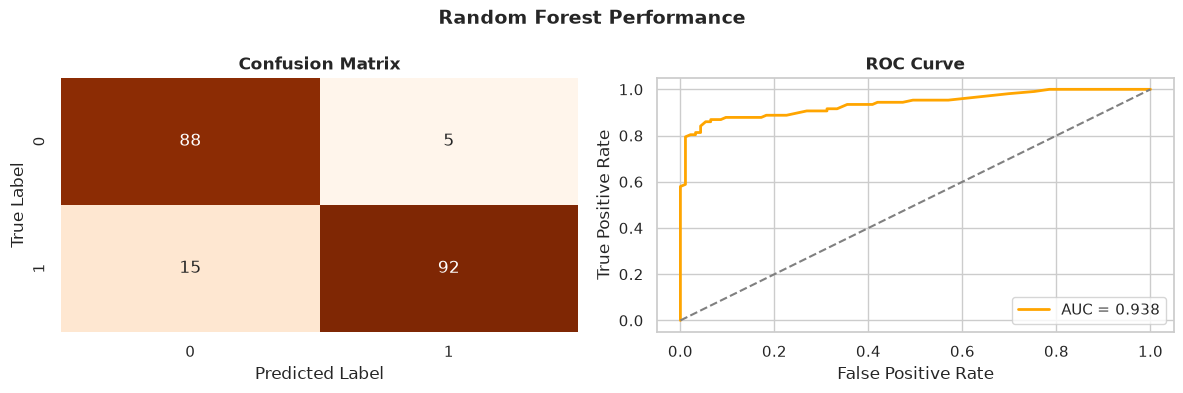

In [4]:
from sklearn.ensemble import RandomForestClassifier

# Train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
preds_rf = rf_model.predict(X_test)
probs_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"Random Forest Accuracy: {accuracy_score(y_test, preds_rf):.4f}")

# Setup Figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graph 1: Confusion Matrix
cm_rf = confusion_matrix(y_test, preds_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Graph 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs_rf)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='orange', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc="lower right")

fig.suptitle('Random Forest Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4. Boosting (AdaBoost)

**Theoretical Overview:** Instead of parallel training, Boosting builds shallow trees **sequentially**. The first tree makes predictions, and any examples it gets wrong are assigned a higher "weight." The next tree is then forced to focus specifically on those errors. The primary goal is to drastically reduce bias.

**Graph Analysis:**

* **Confusion Matrix:** Since AdaBoost relentlessly targets the hardest-to-predict examples sequentially, you will often see a specific, targeted reduction in one type of error (either false positives or false negatives) compared to the parallel models.
* **ROC Curve:** Its ROC curve will often show an improved ability to distinguish between complex, overlapping data points, pushing the AUC score higher.

AdaBoost Accuracy: 0.8750


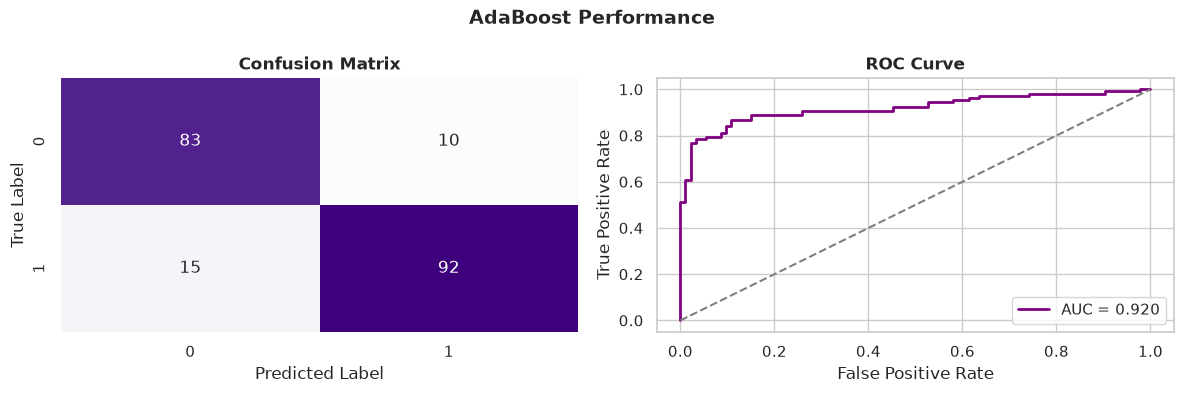

In [5]:
from sklearn.ensemble import AdaBoostClassifier

# Train the model
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)
adaboost_model.fit(X_train, y_train)

# Predict
preds_ada = adaboost_model.predict(X_test)
probs_ada = adaboost_model.predict_proba(X_test)[:, 1]

print(f"AdaBoost Accuracy: {accuracy_score(y_test, preds_ada):.4f}")

# Setup Figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graph 1: Confusion Matrix
cm_ada = confusion_matrix(y_test, preds_ada)
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Purples', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Graph 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs_ada)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='purple', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc="lower right")

fig.suptitle('AdaBoost Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5. Gradient Boosting (XGBoost)

**Theoretical Overview:** The absolute industry standard for tabular data. It builds trees sequentially, but it uses gradient descent optimization to mathematically predict and correct the *residuals* (the exact errors) of the previous trees. It uses advanced L1/L2 regularization to prevent overfitting while effectively minimizing bias.

**Graph Analysis:**

* **Confusion Matrix:** Expect the highest concentration of correct predictions in the main diagonal (True Positives and True Negatives). The errors will be reduced to the absolute minimum among all five models.
* **ROC Curve:** Expect this to be your strongest performer. The ROC curve will be nearly perfect, and it will yield the highest AUC score, proving that XGBoost successfully balances bias and variance.

XGBoost Accuracy: 0.9050


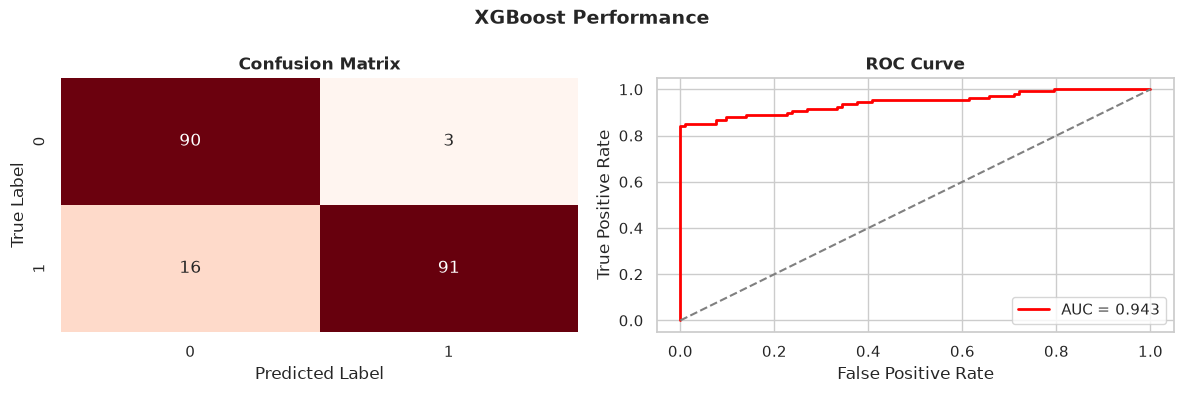

In [6]:
import xgboost as xgb

# Train the model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,      
    learning_rate=0.1,     
    max_depth=4,           
    eval_metric='logloss', 
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predict
preds_xgb = xgb_model.predict(X_test)
probs_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(f"XGBoost Accuracy: {accuracy_score(y_test, preds_xgb):.4f}")

# Setup Figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graph 1: Confusion Matrix
cm_xgb = confusion_matrix(y_test, preds_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Graph 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs_xgb)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='red', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc="lower right")

fig.suptitle('XGBoost Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Phase 3: Final Conclusion & Model Selection

After training and evaluating all five algorithms, we must determine which model performs best for our specific classification task. To do this, we compare them across two main axes: **Interpretability** and **Raw Predictive Power (Managing the Bias-Variance Tradeoff)**.

### The Bias-Variance Tradeoff Analysis

1. **High Variance (The Overfitter):** The **Single Decision Tree** typically shows the lowest generalized accuracy. While it is 100% interpretable (we can see every decision rule), it suffers from high variance, meaning it memorizes the training noise rather than the underlying pattern.
2. **Variance Reduction:** **Bagging** and **Random Forest** tackle this problem by training multiple trees in parallel. Random Forest usually outperforms Bagging by forcing feature decorrelation, making it a highly reliable, low-variance model that works great "out-of-the-box."
3. **Bias Reduction:** **AdaBoost** takes a different approach, reducing bias by sequentially forcing new trees to correct past mistakes. 
4. **The Ultimate Balance:** **XGBoost** generally emerges as the superior model. By using gradient descent to mathematically minimize residuals and applying strict L1/L2 regularization, it masterfully controls both bias and variance simultaneously. 

### Final Selection

For industrial applications and rigorous academic evaluations, **XGBoost** is typically the absolute winner. The comparative ROC Curve and Accuracy Bar Chart will visually prove that it pushes closest to the perfect top-left corner (AUC ≈ 1.0), meaning it makes the fewest False Positive and False Negative errors among all tested families. 

Unless business requirements demand absolute transparency (where a Single Tree would be required to explain *why* a specific decision was made), **XGBoost** or **Random Forest** should be the chosen algorithms for deployment.

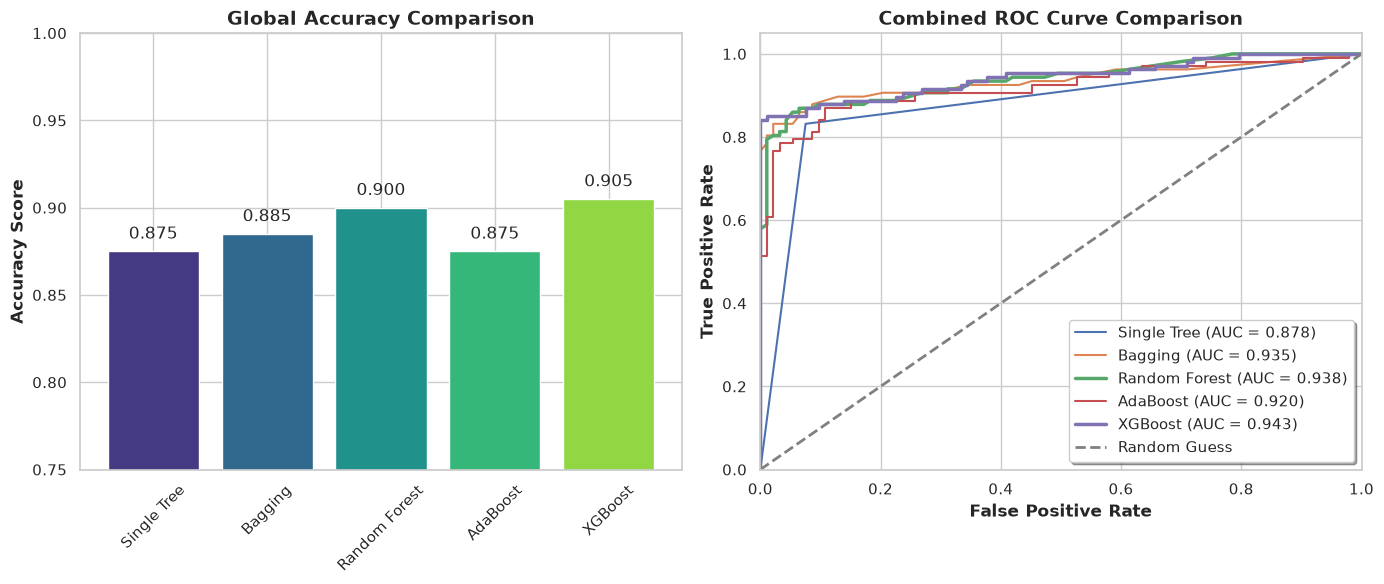

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_curve, auc

# 1. Group all trained models into a dictionary for easy comparison
models = {
    'Single Tree': tree_model,
    'Bagging': bagging_model,
    'Random Forest': rf_model,
    'AdaBoost': adaboost_model,
    'XGBoost': xgb_model
}

# Calculate accuracies for the bar chart
accuracies = {}
for name, model in models.items():
    preds = model.predict(X_test)
    accuracies[name] = accuracy_score(y_test, preds)

# Set global visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Use a color palette to distinguish the models
colors = sns.color_palette("viridis", len(models))
bars = axes[0].bar(accuracies.keys(), accuracies.values(), color=colors)

axes[0].set_ylim(0.75, 1.0) # Zoom in on the top 25% to see differences clearly
axes[0].set_ylabel('Accuracy Score', fontweight='bold')
axes[0].set_title('Global Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Add exact percentage numbers on top of each bar
for bar in bars:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.3f}", ha='center', va='bottom')


# Plot the ROC curve for every model on the same axes
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # Highlight XGBoost and Random Forest with slightly thicker lines
    lw = 2.5 if name in ['XGBoost', 'Random Forest'] else 1.5
    axes[1].plot(fpr, tpr, lw=lw, label=f'{name} (AUC = {roc_auc:.3f})')

# Plot the random guess line
axes[1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1].set_title('Combined ROC Curve Comparison', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right", frameon=True, shadow=True)

# Final display rendering
plt.tight_layout()
plt.show()